# 01 - Análise Exploratória (EDA)

Projeto: em quais países emergentes um milionário deveria investir para gerar maior impacto?

Antes de qualquer modelo, vamos entender os dados: quais países estão sendo analisados, quais indicadores temos e o que eles já revelam sobre as necessidades de cada país.

## Importando as bibliotecas

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import checar_qualidade, TODAS_AS_FEATURES
from src.visualization import configurar_estilo

configurar_estilo()

## Carregando os dados

In [2]:
df = pd.read_csv('../data/raw/dataset_paises.csv')
print(f"{df.shape[0]} países, {df.shape[1] - 1} indicadores")
df.head()

167 países, 9 indicadores


,pais,mortalidade_infantil,exportacoes,saude,importacoes,renda,inflacao,expectativa_vida,fertilidade_total,pib_per_capita
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Qualidade dos dados

In [3]:
#Visualização Geral dos Dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pais                  167 non-null    str    
 1   mortalidade_infantil  167 non-null    float64
 2   exportacoes           167 non-null    float64
 3   saude                 167 non-null    float64
 4   importacoes           167 non-null    float64
 5   renda                 167 non-null    int64  
 6   inflacao              167 non-null    float64
 7   expectativa_vida      167 non-null    float64
 8   fertilidade_total     167 non-null    float64
 9   pib_per_capita        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [4]:
#Verificando nulos e duplicados
qualidade = checar_qualidade(df)
print("Valores nulos por coluna:")
print(qualidade["nulos_por_coluna"])
print("\nPaíses duplicados:", qualidade["paises_duplicados"])

Valores nulos por coluna:
pais                    0
mortalidade_infantil    0
exportacoes             0
saude                   0
importacoes             0
renda                   0
inflacao                0
expectativa_vida        0
fertilidade_total       0
pib_per_capita          0
dtype: int64

Países duplicados: 0


Sem nulos, sem duplicados. A base está limpa.

In [5]:
#Verificando estatísticas descritivas
qualidade["describe"]

,count,mean,std,min,25%,50%,75%,max
mortalidade_infantil,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exportacoes,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
saude,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
importacoes,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
renda,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflacao,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
expectativa_vida,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
fertilidade_total,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
pib_per_capita,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


Um ponto a ser observado é que `renda` e `pib_per_capita` variam de menos de mil até mais de cem mil, uma escala bem maior que a de `expectativa_vida` (que vai só de ~30 a ~83 anos), por exemplo.

## Distribuição dos indicadores

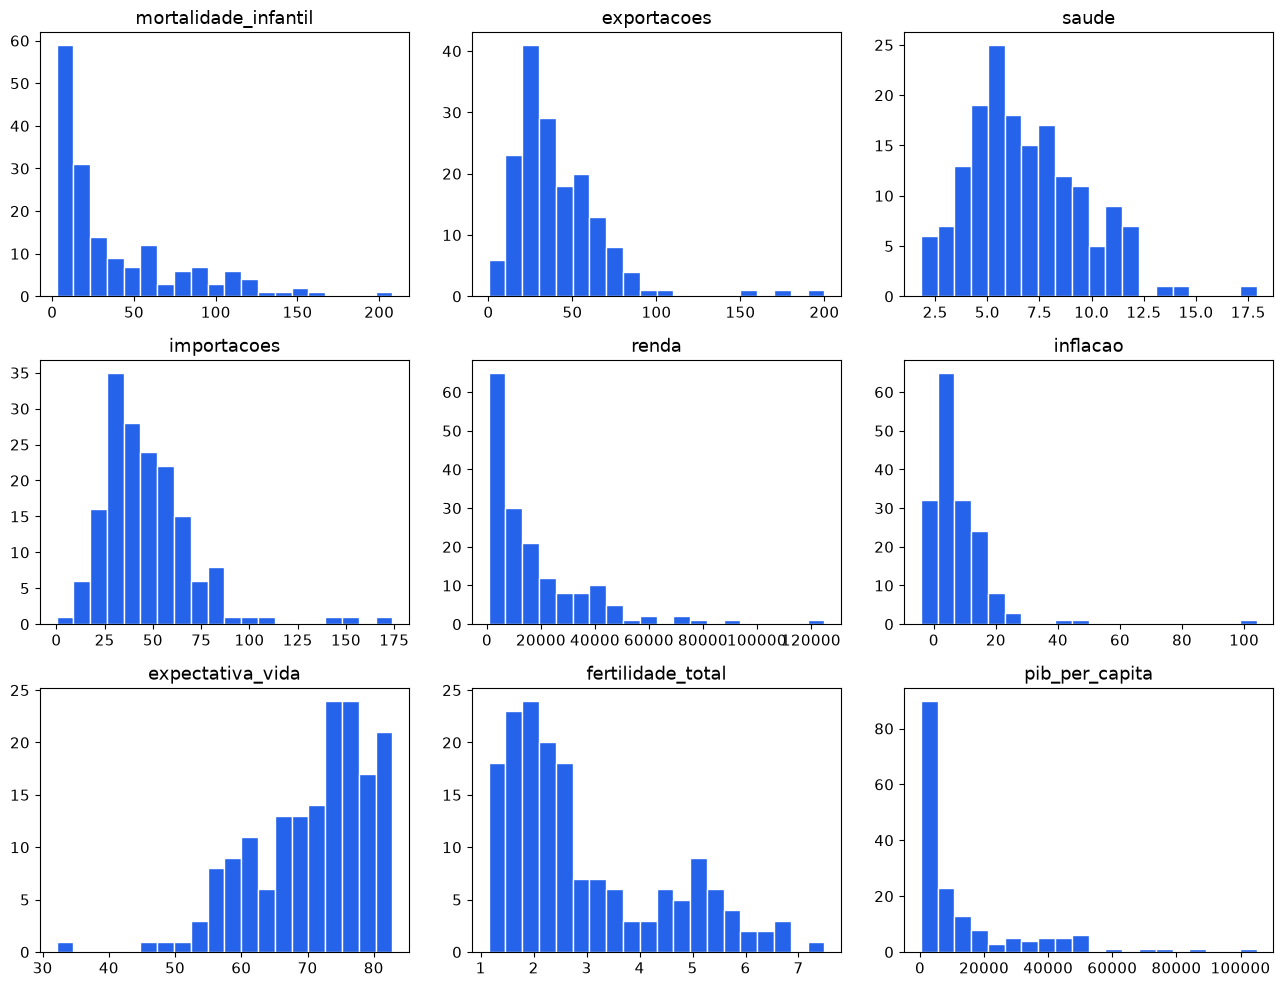

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, TODAS_AS_FEATURES):
    ax.hist(df[col], bins=20, color='#2563eb', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

* Praticamente todos os indicadores têm uma cauda à direita

* A maioria dos países fica concentrada numa faixa "comum", e um grupo menor puxa a distribuição para valores bem mais altos;

* Renda, PIB per capita e exportações são os casos mais claros (uns poucos países muito
ricos ou muito abertos ao comércio exterior);

* Apenas expectativa de vida possui uma cauda para esquerda.

## Correlação entre indicadores

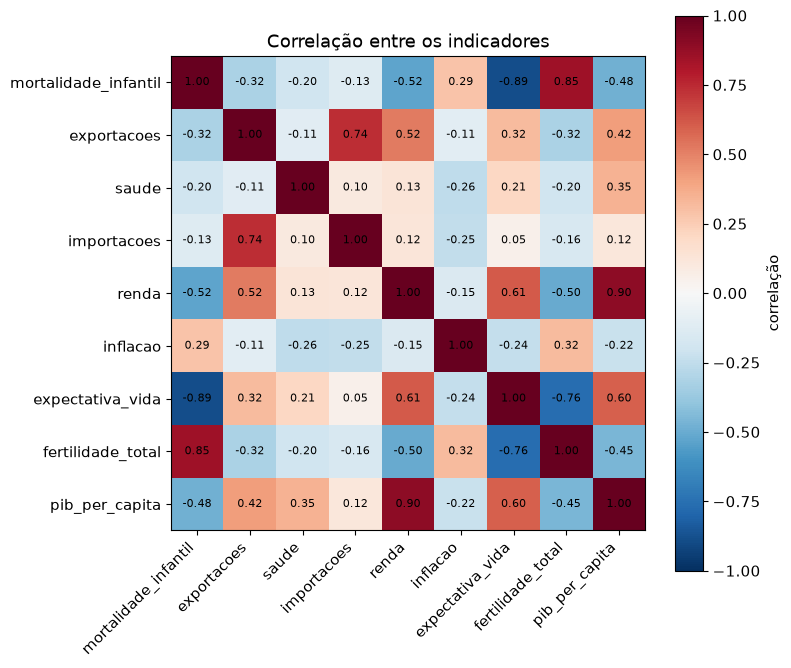

In [7]:
corr = df[TODAS_AS_FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(TODAS_AS_FEATURES)))
ax.set_yticks(range(len(TODAS_AS_FEATURES)))
ax.set_xticklabels(TODAS_AS_FEATURES, rotation=45, ha='right')
ax.set_yticklabels(TODAS_AS_FEATURES)
for i in range(len(TODAS_AS_FEATURES)):
    for j in range(len(TODAS_AS_FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='correlação')
ax.set_title('Correlação entre os indicadores')
plt.tight_layout()
plt.show()

Alguns pares chamam atenção por terem correlação forte (acima de 0,75):

- `mortalidade_infantil` e `expectativa_vida` (-0,89) : faz total sentido, países onde mais crianças morrem também têm expectativa de vida menor;
- `mortalidade_infantil` e `fertilidade_total` (0,85): países com mais filhos por mulher tendem a ter mais mortes infantis também;
- `renda` e `pib_per_capita` (0,90): as duas são formas diferentes de medir a mesma coisa: quanto dinheiro circula por pessoa naquele país.